In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('./placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


[]

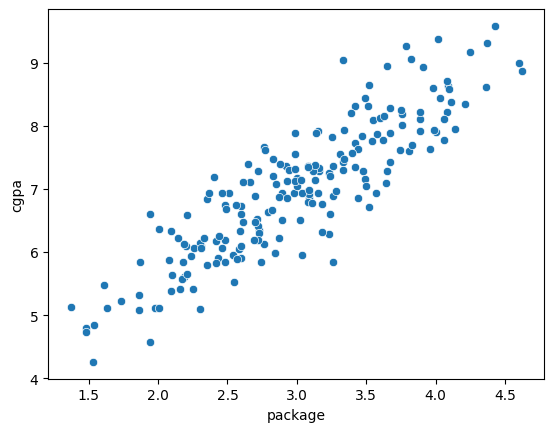

In [3]:
sns.scatterplot(df,x='package',y='cgpa')
plt.plot()

In [4]:
X = df.iloc[:,0]
y = df.iloc[:,1]

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train.to_frame(),y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
X_test

112    8.58
29     7.15
182    5.88
199    6.22
193    4.57
85     4.79
10     5.32
54     6.86
115    8.35
35     6.87
12     8.94
92     7.90
13     6.93
126    5.91
174    7.32
2      7.82
44     5.09
3      7.42
113    6.94
14     7.73
23     6.19
25     7.28
6      6.73
134    7.20
165    8.21
173    6.75
45     7.87
65     7.60
48     8.63
122    5.12
178    8.15
64     7.36
9      8.31
57     6.60
78     6.59
71     7.47
128    7.93
176    6.29
131    6.37
53     6.47
Name: cgpa, dtype: float64

In [11]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [12]:
lr.predict(X_test.iloc[1].reshape(1,1))

E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

In [13]:
lr.predict(X_test.iloc[2].reshape(-1,1))

E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

Text(0, 0.5, 'Package(in lpa)')

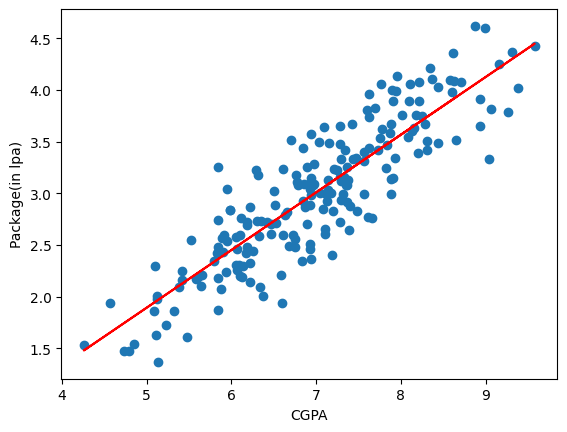

In [14]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train.to_frame()),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [15]:
m = lr.coef_

In [16]:
b = lr.intercept_

In [17]:
# y = mx + b
m * X_test.iloc[1] + b

array([3.09324469])

In [18]:
## calculate mac
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
y_pred =  lr.predict(X_test.to_frame())

In [20]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

## check error usgin some function

In [21]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [22]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [23]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [24]:
print("r2score",r2 := r2_score(y_test,y_pred))

r2score 0.780730147510384


In [25]:
## adjeusted r2 score
1 - ((1-r2) * (40-1) / (40-1-1))

0.7749598882343415

In [26]:
new_df1 = df.copy()
# new_df1['random_feature'] = np.random.random(new_df1.shape[0])
new_df1.insert(1,'random_feature',np.random.random(new_df1.shape[0]))
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.670609,3.26
1,5.12,0.875918,1.98
2,7.82,0.504730,3.25
3,7.42,0.089792,3.67
4,6.94,0.946965,3.57


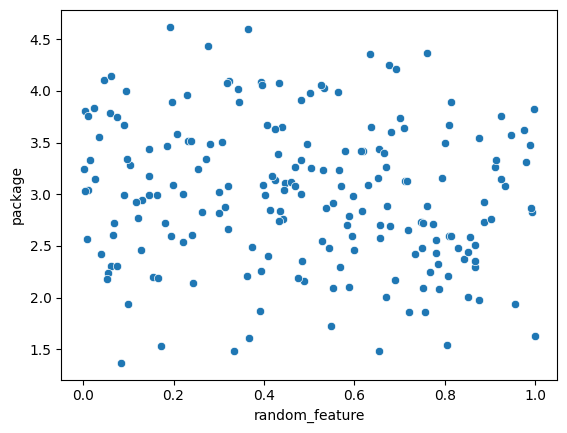

In [27]:
sns.scatterplot(new_df1,x='random_feature',y='package')
plt.show()

In [28]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=2,train_size=0.2)

In [30]:
lr = LinearRegression()

In [31]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = lr.predict(X_test)

In [33]:
print("r2score",r2 := r2_score(y_test,y_pred))

r2score 0.7516959974898747


In [34]:
1 - ((1 - r2) * (40 - 1) / (40 - 1 - 2))

0.7382741595163544

In [35]:
new_df2 = df.copy()

new_df2.insert(1,'iq',new_df2['package'] + np.random.randint(-12,12,200)/10)
# # new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)
# new_df2 = new_df2[['cgpa','iq','package']]

In [36]:
new_df2.sample(5)

,cgpa,iq,package
18,6.94,3.98,2.98
144,6.17,2.22,2.42
94,5.83,2.82,2.42
6,6.73,3.20,2.60
17,5.38,1.39,2.09


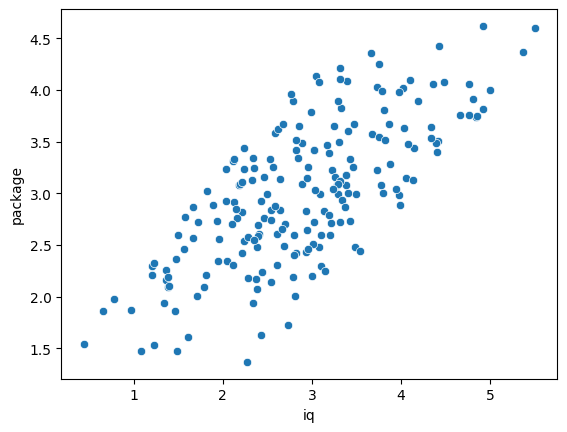

In [37]:
sns.scatterplot(new_df2,x='iq',y='package')
plt.show()

In [38]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=2,train_size=0.2)

In [40]:
lr = LinearRegression()

In [41]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
X_train.shape

(40, 2)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print('R2 Score',r2 := r2_score(y_test,y_pred))

In [ ]:
1 - ((1 - r2) * (40 - 1) / (40 - 1 - 2))